STEP 1 — LOADING DATASET
  ✔ Loaded  : 21,214 rows × 9 columns
  Columns   : ['Reviewer Name', 'Profile Link', 'Country', 'Review Count', 'Review Date', 'Rating', 'Review Title', 'Review Text', 'Date of Experience']
  Data types:
Reviewer Name         object
Profile Link          object
Country               object
Review Count          object
Review Date           object
Rating                object
Review Title          object
Review Text           object
Date of Experience    object

STEP 2 — AUTO-DETECTING TEXT & TARGET COLUMNS
  ✔ Text column     : 'Review Text'
  ✔ Target column   : 'Rating'

STEP 3 — ENGINEERING SENTIMENT LABELS
  Detected string labels. Unique values: ['Rated 1 out of 5 stars', 'Rated 2 out of 5 stars', 'Rated 3 out of 5 stars', 'Rated 4 out of 5 stars', 'Rated 5 out of 5 stars']
  ✔ Extracted numeric ratings from strings, mapped 4-5 → Positive | 1-2 → Negative

  Class distribution:
sentiment
Negative    14509
Positive     5820

STEP 4 — TEXT PREPROCESSING
  A

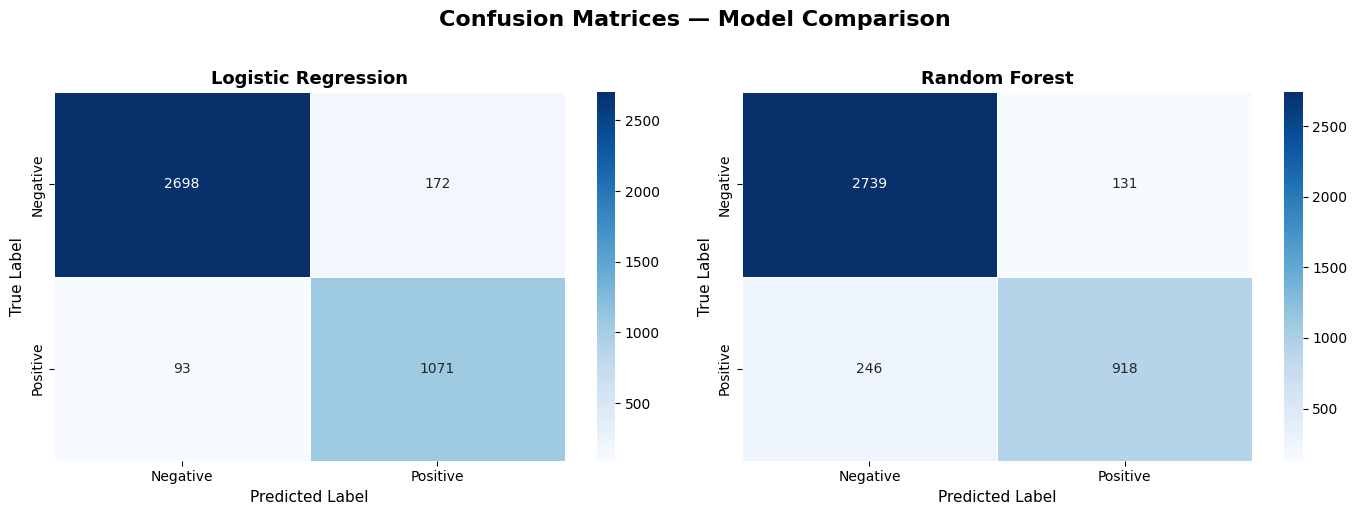

  ✔ Confusion matrices saved as 'confusion_matrices.png'



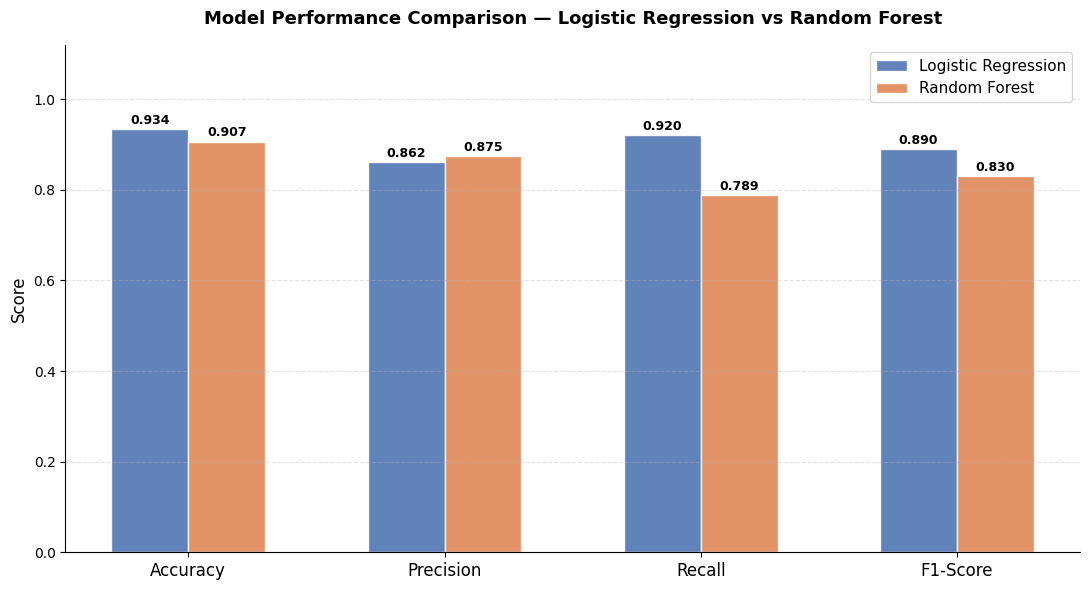

  ✔ Comparison chart saved as 'model_comparison.png'


FINAL PERFORMANCE COMPARISON
                    Accuracy Precision   Recall F1-Score
Model                                                   
Logistic Regression  93.43 %   86.16 %  92.01 %  88.99 %
Random Forest        90.65 %   87.51 %  78.87 %  82.96 %

  🏆  Best model by F1-Score : Logistic Regression  (88.99 %)


In [ ]:
# =============================================================================
# SENTIMENT ANALYSIS PIPELINE — Logistic Regression vs Random Forest
# Compatible with Google Colab | Fully Auto-Detecting Column Names
# =============================================================================

# ── 0. Install dependencies (uncomment in Colab if needed) ──────────────────
# !pip install scikit-learn pandas numpy matplotlib seaborn nltk

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import nltk
nltk.download("stopwords", quiet=True)
nltk.download("punkt",     quiet=True)
from nltk.corpus import stopwords

STOP_WORDS = set(stopwords.words("english"))

# =============================================================================
# SECTION 1 — DATA LOADING
# =============================================================================

def load_data(filepath: str) -> pd.DataFrame:
    """Load CSV dataset and display a quick summary."""
    print("=" * 65)
    print("STEP 1 — LOADING DATASET")
    print("=" * 65)
    df = pd.read_csv(filepath, encoding="utf-8", on_bad_lines="skip", engine='python')
    print(f"  ✔ Loaded  : {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"  Columns   : {list(df.columns)}")
    print(f"  Data types:\n{df.dtypes.to_string()}\n")
    return df


# =============================================================================
# SECTION 2 — AUTO-DETECT TEXT & LABEL COLUMNS
# =============================================================================

def detect_columns(df: pd.DataFrame):
    """
    Heuristically detect which column holds review text
    and which column holds the sentiment/rating label.
    """
    print("=" * 65)
    print("STEP 2 — AUTO-DETECTING TEXT & TARGET COLUMNS")
    print("=" * 65)

    # Common column name patterns, prioritized for specificity
    text_hints      = ["review text", "review_text", "text", "comment", "body", "content", "summary", "review"]
    sentiment_hints = ["sentiment", "label", "score", "rating", "stars", "overall", "class", "polarity"]

    text_col      = None
    sentiment_col = None

    lower_cols = {col.lower().strip(): col for col in df.columns}

    # --- Detect text column (prefer longer average string length or specific hints)
    for hint in text_hints:
        for lc, original in lower_cols.items():
            if hint in lc and df[original].dtype == object:
                text_col = original
                break
        if text_col:
            break

    # Fallback: pick the object column with the longest average text
    if text_col is None:
        obj_cols = df.select_dtypes(include="object").columns.tolist()
        if obj_cols:
            avg_len = {c: df[c].dropna().apply(lambda x: len(str(x))).mean() for c in obj_cols}
            text_col = max(avg_len, key=avg_len.get)

    # --- Detect sentiment / label column
    for hint in sentiment_hints:
        for lc, original in lower_cols.items():
            if hint in lc and original != text_col: # Ensure it's not the text column
                sentiment_col = original
                break
        if sentiment_col:
            break

    # Fallback: pick a low-cardinality column that isn't the text column
    if sentiment_col is None:
        for col in df.columns:
            if col != text_col and df[col].nunique() <= 10:
                sentiment_col = col
                break

    print(f"  ✔ Text column     : '{text_col}'")
    print(f"  ✔ Target column   : '{sentiment_col}'\n")
    return text_col, sentiment_col


# =============================================================================
# SECTION 3 — LABEL ENGINEERING
# =============================================================================

def engineer_labels(df: pd.DataFrame, sentiment_col: str) -> pd.DataFrame:
    """
    Convert numeric ratings → Positive / Negative sentiment labels.
    If the column already contains string labels, map to binary.
    """
    print("=" * 65)
    print("STEP 3 — ENGINEERING SENTIMENT LABELS")
    print("=" * 65)

    col = df[sentiment_col].dropna()

    # Numeric rating column (e.g. 1-5 stars)
    if pd.api.types.is_numeric_dtype(col):
        print(f"  Detected numeric ratings. Unique values: {sorted(col.unique())}")
        # Drop neutral (3-star) rows for cleaner binary task; map 1-2 → Negative, 4-5 → Positive
        df = df[df[sentiment_col] != 3].copy()
        df["sentiment"] = df[sentiment_col].apply(
            lambda x: "Positive" if x >= 4 else "Negative"
        )
        print("  ✔ Mapped  ratings 4-5 → Positive  |  1-2 → Negative")
    else:
        # String labels — normalise by extracting numeric rating if possible
        temp_ratings = []
        for val in col:
            match = re.search(r'\d+', str(val))
            if match:
                temp_ratings.append(int(match.group()))
            else:
                temp_ratings.append(np.nan)

        df["_temp_numeric_rating"] = pd.Series(temp_ratings, index=col.index)
        print(f"  Detected string labels. Unique values: {sorted(col.unique())}")
        # Drop neutral (3-star) rows and map 1-2 → Negative, 4-5 → Positive
        df = df[df["_temp_numeric_rating"] != 3].copy()
        df["sentiment"] = df["_temp_numeric_rating"].apply(
            lambda x: "Positive" if x >= 4 else "Negative"
        )
        df.drop(columns=["_temp_numeric_rating"], inplace=True)
        print("  ✔ Extracted numeric ratings from strings, mapped 4-5 → Positive | 1-2 → Negative")

    print(f"\n  Class distribution:\n{df['sentiment'].value_counts().to_string()}\n")
    return df


# =============================================================================
# SECTION 4 — TEXT CLEANING
# =============================================================================

def clean_text(text: str) -> str:
    """Lowercase, remove HTML/URLs/punctuation, strip numbers, remove stopwords."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)           # remove HTML tags
    text = re.sub(r"http\S+|www\S+", " ", text)     # remove URLs
    text = re.sub(r"\d+", " ", text)                # remove digits
    text = text.translate(str.maketrans("", "", string.punctuation))  # punctuation
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 1]
    return " ".join(tokens)


def preprocess_text(df: pd.DataFrame, text_col: str) -> pd.DataFrame:
    """Apply text cleaning to the review column."""
    print("=" * 65)
    print("STEP 4 — TEXT PREPROCESSING")
    print("=" * 65)
    print("  Applying: lowercase → HTML removal → URL removal → digit removal")
    print("            → punctuation removal → stopword removal …")
    df = df.dropna(subset=[text_col]).copy()
    df["clean_text"] = df[text_col].apply(clean_text)
    df = df[df["clean_text"].str.strip() != ""].copy()   # drop empty results
    print(f"  ✔ Done. {len(df):,} reviews remain after cleaning.\n")
    return df


# =============================================================================
# SECTION 5 — TF-IDF VECTORISATION & TRAIN / TEST SPLIT
# =============================================================================

def vectorize_and_split(df: pd.DataFrame, test_size: float = 0.20, max_features: int = 15_000):
    """TF-IDF vectorisation followed by stratified train/test split."""
    print("=" * 65)
    print("STEP 5 — TF-IDF VECTORISATION & TRAIN/TEST SPLIT")
    print("=" * 65)

    X_raw = df["clean_text"]
    y     = df["sentiment"]

    # Encode labels
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    # Split first (fit TF-IDF only on training data to prevent leakage)
    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_raw, y_enc, test_size=test_size, random_state=42, stratify=y_enc
    )

    vectorizer = TfidfVectorizer(
        max_features=max_features,
        ngram_range=(1, 2),     # unigrams + bigrams
        sublinear_tf=True,      # apply log normalisation
        min_df=2
    )
    X_train = vectorizer.fit_transform(X_train_raw)
    X_test  = vectorizer.transform(X_test_raw)

    print(f"  ✔ Vocabulary size      : {len(vectorizer.vocabulary_):,} features")
    print(f"  ✔ Training samples     : {X_train.shape[0]:,}")
    print(f"  ✔ Test samples         : {X_test.shape[0]:,}")
    print(f"  ✔ Feature matrix shape : {X_train.shape}\n")

    return X_train, X_test, y_train, y_test, vectorizer, le


# =============================================================================
# SECTION 6 — MODEL TRAINING
# =============================================================================

def train_logistic_regression(X_train, y_train) -> LogisticRegression:
    print("=" * 65)
    print("STEP 6a — TRAINING LOGISTIC REGRESSION")
    print("=" * 65)
    model = LogisticRegression(
        max_iter=500,
        C=1.0,
        solver="lbfgs",
        class_weight="balanced",
        random_state=42
    )
    model.fit(X_train, y_train)
    print("  ✔ Logistic Regression training complete.\n")
    return model


def train_random_forest(X_train, y_train) -> RandomForestClassifier:
    print("=" * 65)
    print("STEP 6b — TRAINING RANDOM FOREST CLASSIFIER")
    print("=" * 65)
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42
    )
    model.fit(X_train, y_train)
    print("  ✔ Random Forest training complete.\n")
    return model


# =============================================================================
# SECTION 7 — EVALUATION
# =============================================================================

def evaluate_model(model, X_test, y_test, label_encoder, model_name: str) -> dict:
    """Compute all metrics and return a results dictionary."""
    print(f"\n{'=' * 65}")
    print(f"STEP 7 — EVALUATING : {model_name}")
    print("=" * 65)

    y_pred   = model.predict(X_test)
    classes  = label_encoder.classes_
    avg_type = "binary" if len(classes) == 2 else "weighted"

    metrics = {
        "Model"    : model_name,
        "Accuracy" : accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average=avg_type, zero_division=0),
        "Recall"   : recall_score(y_test, y_pred,    average=avg_type, zero_division=0),
        "F1-Score" : f1_score(y_test, y_pred,        average=avg_type, zero_division=0),
        "y_pred"   : y_pred,
    }

    print(f"\n  Accuracy  : {metrics['Accuracy']:.4f}")
    print(f"  Precision : {metrics['Precision']:.4f}")
    print(f"  Recall    : {metrics['Recall']:.4f}")
    print(f"  F1-Score  : {metrics['F1-Score']:.4f}")
    print(f"\n  Classification Report:\n")
    print(classification_report(y_test, y_pred, target_names=classes, zero_division=0))

    return metrics


# =============================================================================
# SECTION 8 — VISUALISATIONS
# =============================================================================

def plot_confusion_matrices(results: list, y_test, label_encoder):
    """Side-by-side confusion matrices for both models."""
    classes = label_encoder.classes_
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Confusion Matrices — Model Comparison", fontsize=16, fontweight="bold", y=1.02)

    for ax, res in zip(axes, results):
        cm = confusion_matrix(y_test, res["y_pred"])
        sns.heatmap(
            cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes,
            linewidths=0.5, ax=ax
        )
        ax.set_title(res["Model"], fontsize=13, fontweight="bold")
        ax.set_xlabel("Predicted Label", fontsize=11)
        ax.set_ylabel("True Label",      fontsize=11)

    plt.tight_layout()
    plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  ✔ Confusion matrices saved as 'confusion_matrices.png'\n")


def plot_metrics_comparison(results: list):
    """Grouped bar chart comparing all four metrics across both models."""
    metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
    model_names  = [r["Model"] for r in results]
    palette      = ["#4C72B0", "#DD8452"]

    values = np.array([[r[m] for m in metric_names] for r in results])

    x     = np.arange(len(metric_names))
    width = 0.30
    fig, ax = plt.subplots(figsize=(11, 6))

    for i, (model_vals, color, name) in enumerate(zip(values, palette, model_names)):
        bars = ax.bar(x + i * width, model_vals, width, label=name, color=color, alpha=0.88, edgecolor="white")
        for bar, val in zip(bars, model_vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{val:.3f}",
                ha="center", va="bottom", fontsize=9, fontweight="bold"
            )

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(metric_names, fontsize=12)
    ax.set_ylim(0, 1.12)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title("Model Performance Comparison — Logistic Regression vs Random Forest",
                 fontsize=13, fontweight="bold", pad=15)
    ax.legend(fontsize=11, loc="upper right")
    ax.grid(axis="y", alpha=0.35, linestyle="--")
    sns.despine()

    plt.tight_layout()
    plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  ✔ Comparison chart saved as 'model_comparison.png'\n")


# =============================================================================
# SECTION 9 — FINAL COMPARISON TABLE
# =============================================================================

def print_comparison_table(results: list):
    """Print a clean summary table and declare the winner."""
    print("\n" + "=" * 65)
    print("FINAL PERFORMANCE COMPARISON")
    print("=" * 65)

    metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
    summary = [{k: v for k, v in r.items() if k != "y_pred"} for r in results]
    df_summary = pd.DataFrame(summary).set_index("Model")

    # Format as percentages
    df_display = (df_summary[metric_names] * 100).round(2).astype(str) + " %"
    print(df_display.to_string())

    # Declare winner based on F1-Score
    best_idx   = df_summary["F1-Score"].idxmax()
    best_score = df_summary.loc[best_idx, "F1-Score"]
    print(f"\n  🏆  Best model by F1-Score : {best_idx}  ({best_score*100:.2f} %)")
    print("=" * 65)

    return df_summary


# =============================================================================
# MAIN PIPELINE
# =============================================================================

def run_pipeline(filepath: str):
    """End-to-end execution of the sentiment analysis pipeline."""

    # 1. Load
    df = load_data(filepath)

    # 2. Detect columns
    text_col, sentiment_col = detect_columns(df)

    # 3. Engineer labels
    df = engineer_labels(df, sentiment_col)

    # 4. Clean text
    df = preprocess_text(df, text_col)

    # 5. Vectorise & split
    X_train, X_test, y_train, y_test, vectorizer, le = vectorize_and_split(df)

    # 6. Train models
    lr_model = train_logistic_regression(X_train, y_train)
    rf_model = train_random_forest(X_train, y_train)

    # 7. Evaluate
    lr_results = evaluate_model(lr_model, X_test, y_test, le, "Logistic Regression")
    rf_results = evaluate_model(rf_model, X_test, y_test, le, "Random Forest")

    results = [lr_results, rf_results]

    # 8. Visualise
    print("\n" + "=" * 65)
    print("STEP 8 — GENERATING VISUALISATIONS")
    print("=" * 65)
    plot_confusion_matrices(results, y_test, le)
    plot_metrics_comparison(results)

    # 9. Summary table
    print_comparison_table(results)

    return lr_model, rf_model, vectorizer, le


# =============================================================================
# ENTRY POINT — change this path to your uploaded CSV in Colab
# =============================================================================

if __name__ == "__main__":
    # ── Google Colab file upload ─────────────────────────────────────────────
    # Uncomment the block below if you want to upload interactively in Colab:
    #
    # from google.colab import files
    # uploaded = files.upload()
    # filepath = list(uploaded.keys())[0]
    #
    # ── OR hard-code the path after uploading via the Files panel ────────────
    filepath = "/content/Amazon_Reviews.csv"   # ← Update this path if needed

    lr_model, rf_model, vectorizer, le = run_pipeline(filepath)


╔═══════════════════════════════════════════════════════════════╗
║  STEP 1 — LOADING DATASET                                     ║
╚═══════════════════════════════════════════════════════════════╝
  ✔ Shape    : 21,214 rows × 9 columns
  ✔ Columns  : ['Reviewer Name', 'Profile Link', 'Country', 'Review Count', 'Review Date', 'Rating', 'Review Title', 'Review Text', 'Date of Experience']
  ✔ Dtypes   :
Reviewer Name         object
Profile Link          object
Country               object
Review Count          object
Review Date           object
Rating                object
Review Title          object
Review Text           object
Date of Experience    object

╔═══════════════════════════════════════════════════════════════╗
║  STEP 2 — AUTO-DETECTING TEXT & TARGET COLUMNS               ║
╚═══════════════════════════════════════════════════════════════╝
  ✔ Text column   : 'Review Text'
  ✔ Target column : 'Rating'

╔═══════════════════════════════════════════════════════════════╗
║  S

Model: "Sentiment_CNN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input (InputLayer)  │ (None, 200)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Embedding           │ (None, 200, 128)  │  2,560,000 │ Input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1D_k2 (Conv1D)  │ (None, 200, 128)  │     32,896 │ Embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1D_k3 (Conv1D)  │ (None, 200, 128)  │     49,280 │ Embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1D_k4 (Conv1D)  │ (None, 200, 128)  │     65,664 │ Embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BN_k2               │ (None, 200, 128)  │        512 │ Conv1D_k2[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BN_k3               │ (None, 200, 128)  │        512 │ Conv1D_k3[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ BN_k4               │ (None, 200, 128)  │        512 │ Conv1D_k4[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MaxPool_k2          │ (None, 100, 128)  │          0 │ BN_k2[0][0]       │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MaxPool_k3          │ (None, 100, 128)  │          0 │ BN_k3[0][0]       │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ MaxPool_k4          │ (None, 100, 128)  │          0 │ BN_k4[0][0]       │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1D_k2_2         │ (None, 100, 64)   │     16,448 │ MaxPool_k2[0][0]  │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1D_k3_2         │ (None, 100, 64)   │     24,640 │ MaxPool_k3[0][0]  │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1D_k4_2         │ (None, 100, 64)   │     32,832 │ MaxPool_k4[0][0]  │
│ (Conv1D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ GlobalPool_k2       │ (None, 64)        │          0 │ Conv1D_k2_2[0][0] │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ GlobalPool_k3       │ (None, 64)        │          0 │ Conv1D_k3_2[0][0] │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ GlobalPool_k4       │ (None, 64)        │          0 │ Conv1D_k4_2[0][0] │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Concat              │ (None, 192)       │          0 │ GlobalPool_k2[0]… │
│ (Concatenate)       │                   │            │ GlobalPool_k3[0]

 Total params: 2,809,409 (10.72 MB)

 Trainable params: 2,808,001 (10.71 MB)

 Non-trainable params: 1,408 (5.50 KB)


  ✔ Loss function : binary_crossentropy
  ✔ Optimizer     : Adam (lr=1e-3)

╔═══════════════════════════════════════════════════════════════╗
║  STEP 7 — TRAINING CNN MODEL                                 ║
╚═══════════════════════════════════════════════════════════════╝
  Batch size : 64  |  Max epochs : 15
  EarlyStopping patience=4  |  ReduceLROnPlateau patience=2

Epoch 1/15
253/253 ━━━━━━━━━━━━━━━━━━━━ 113s 425ms/step - accuracy: 0.8036 - loss: 0.4715 - val_accuracy: 0.3121 - val_loss: 0.7316 - learning_rate: 0.0010
Epoch 2/15
253/253 ━━━━━━━━━━━━━━━━━━━━ 115s 456ms/step - accuracy: 0.9428 - loss: 0.1576 - val_accuracy: 0.7050 - val_loss: 0.5774 - learning_rate: 0.0010
Epoch 3/15
253/253 ━━━━━━━━━━━━━━━━━━━━ 116s 459ms/step - accuracy: 0.9703 - loss: 0.0795 - val_accuracy: 0.9199 - val_loss: 0.2321 - learning_rate: 0.0010
Epoch 4/15
253/253 ━━━━━━━━━━━━━━━━━━━━ 111s 441ms/step - accuracy: 0.9822 - loss: 0.0482 - val_accuracy: 0.9321 - val_loss: 0.2242 - learning_rate: 0.0010
Epo

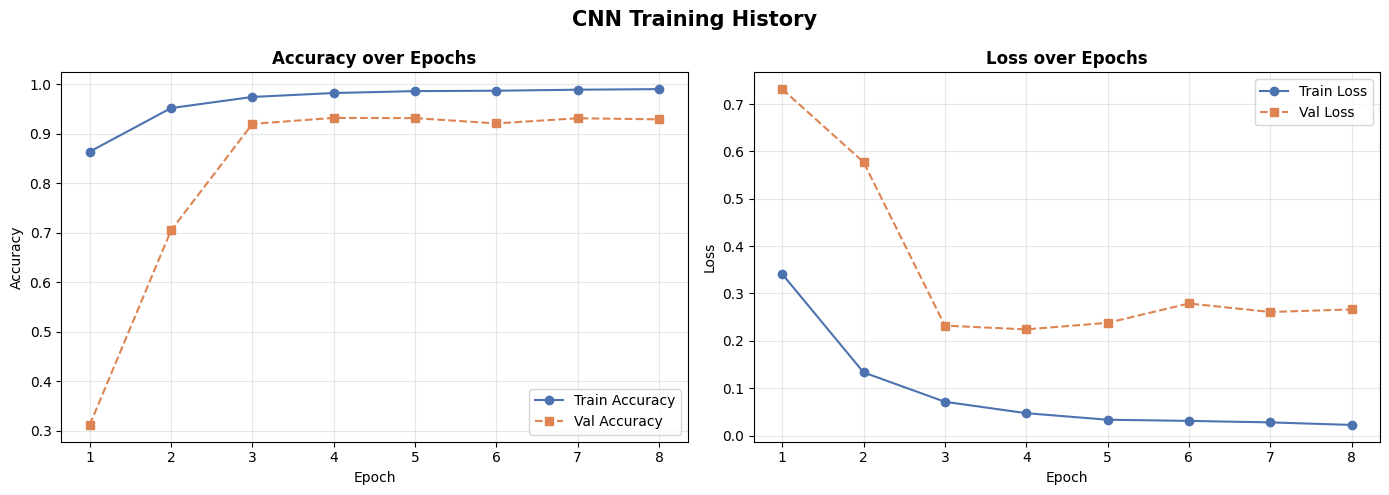

  ✔ Training history saved as 'cnn_training_history.png'



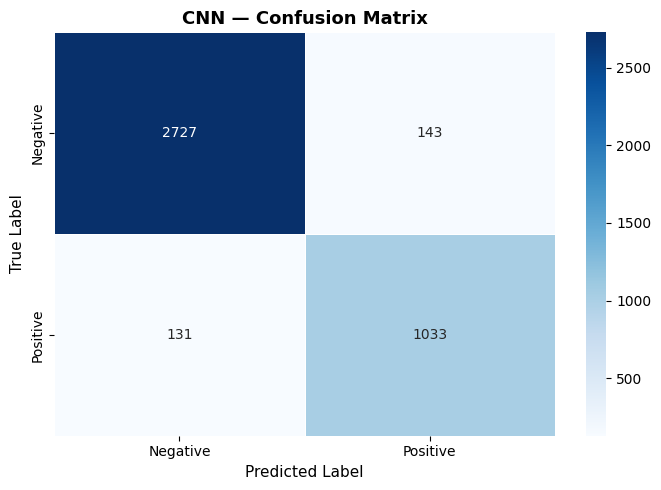

  ✔ Confusion matrix saved as 'cnn_confusion_matrix.png'


╔═══════════════════════════════════════════════════════════════╗
║  STEP 9 — MODEL COMPARISON VISUALISATION                     ║
╚═══════════════════════════════════════════════════════════════╝


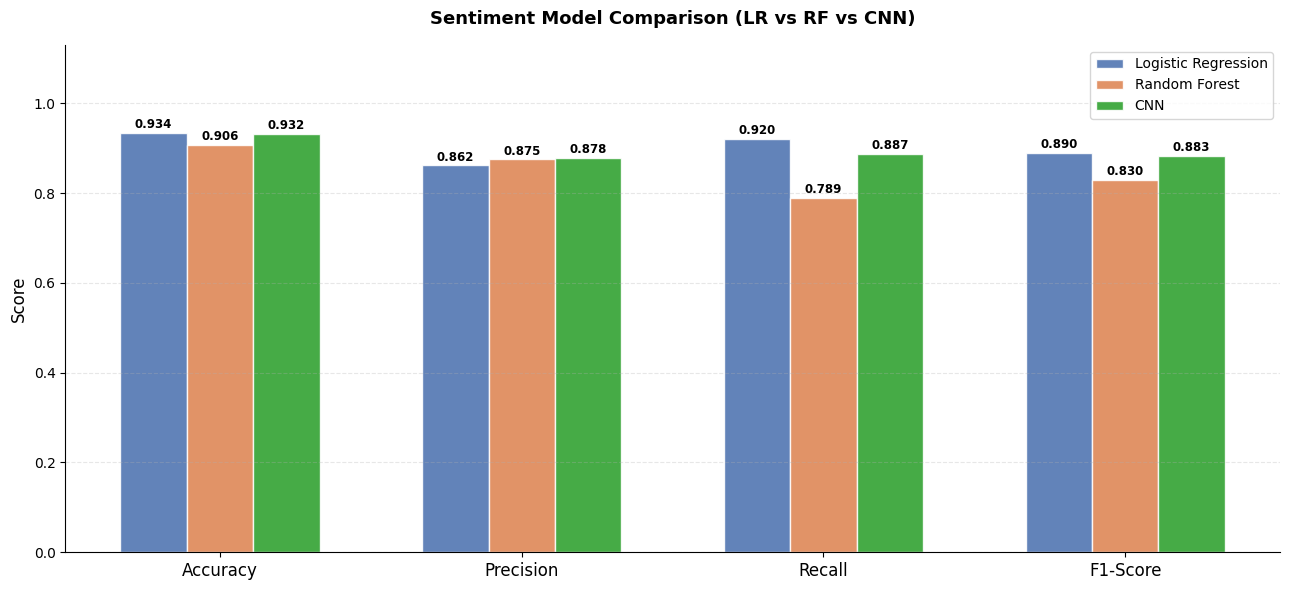

  ✔ Full comparison chart saved as 'full_model_comparison.png'


╔═══════════════════════════════════════════════════════════════╗
║  FINAL MODEL COMPARISON TABLE                                ║
╚═══════════════════════════════════════════════════════════════╝
                    Accuracy Precision   Recall F1-Score
Model                                                   
Logistic Regression  93.43 %   86.16 %  92.01 %  88.99 %
Random Forest        90.65 %   87.51 %  78.87 %  82.96 %
CNN                  93.21 %   87.84 %  88.75 %  88.29 %

  🏆  Best model by F1-Score : Logistic Regression  (88.99 %)


In [1]:
# =============================================================================
# SENTIMENT ANALYSIS — CNN (Convolutional Neural Network) PIPELINE
# TensorFlow / Keras | Google Colab Ready | Auto-Detecting Columns
# =============================================================================

# ── 0. Install / upgrade packages if needed (uncomment in Colab) ─────────────
# !pip install tensorflow scikit-learn pandas numpy matplotlib seaborn nltk

import os, re, string, warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import nltk
nltk.download("stopwords", quiet=True)
from nltk.corpus import stopwords

from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import LabelEncoder
from sklearn.metrics          import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import tensorflow as tf
from tensorflow.keras.preprocessing.text     import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models                 import Model
from tensorflow.keras.layers                 import (
    Input, Embedding, Conv1D, MaxPooling1D,
    GlobalMaxPooling1D, Dropout, Dense,
    BatchNormalization, Concatenate
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Hyper-parameters (edit here if you want to experiment) ──────────────────
MAX_VOCAB    = 20_000   # max vocabulary size
MAX_LEN      = 200      # max token length per review (pad/truncate)
EMBED_DIM    = 128      # embedding vector size
BATCH_SIZE   = 64
EPOCHS       = 15
TEST_SIZE    = 0.20
STOP_WORDS   = set(stopwords.words("english"))


# =============================================================================
# SECTION 1 — DATA LOADING
# =============================================================================

def load_data(filepath: str) -> pd.DataFrame:
    print("\n" + "╔" + "═" * 63 + "╗")
    print("║  STEP 1 — LOADING DATASET" + " " * 37 + "║")
    print("╚" + "═" * 63 + "╝")
    df = pd.read_csv(filepath, encoding="utf-8", on_bad_lines="skip", engine='python')
    print(f"  ✔ Shape    : {df.shape[0]:,} rows × {df.shape[1]} columns")
    print(f"  ✔ Columns  : {list(df.columns)}")
    print(f"  ✔ Dtypes   :\n{df.dtypes.to_string()}")
    return df


# =============================================================================
# SECTION 2 — AUTO-DETECT TEXT & TARGET COLUMNS
# =============================================================================

def detect_columns(df: pd.DataFrame):
    print("\n" + "╔" + "═" * 63 + "╗")
    print("║  STEP 2 — AUTO-DETECTING TEXT & TARGET COLUMNS" + " " * 15 + "║")
    print("╚" + "═" * 63 + "╝")

    # Prioritize specific hints
    text_hints      = ["review text", "review_text", "text", "comment", "body", "content", "summary", "review"]
    sentiment_hints = ["sentiment", "label", "score", "rating", "stars", "overall", "class", "polarity"]

    lower_cols = {col.lower().strip(): col for col in df.columns}
    text_col   = None
    target_col = None

    # --- Detect text column (prefer longer average string length or specific hints)
    for hint in text_hints:
        for lc, original in lower_cols.items():
            if hint in lc and df[original].dtype == object:
                text_col = original
                break
        if text_col:
            break

    # Fallback: pick the object column with the longest average text
    if text_col is None:
        obj_cols = df.select_dtypes(include="object").columns.tolist()
        if obj_cols:
            avg_len  = {c: df[c].dropna().apply(lambda x: len(str(x))).mean() for c in obj_cols}
            text_col = max(avg_len, key=avg_len.get)

    for hint in sentiment_hints:
        for lc, original in lower_cols.items():
            if hint in lc and original != text_col:
                target_col = original
                break
        if target_col:
            break

    if target_col is None:
        for col in df.columns:
            if col != text_col and df[col].nunique() <= 10:
                target_col = col
                break

    print(f"  ✔ Text column   : '{text_col}'")
    print(f"  ✔ Target column : '{target_col}'")
    return text_col, target_col


# =============================================================================
# SECTION 3 — LABEL ENGINEERING
# =============================================================================

def engineer_labels(df: pd.DataFrame, target_col: str) -> pd.DataFrame:
    print("\n" + "╔" + "═" * 63 + "╗")
    print("║  STEP 3 — ENGINEERING SENTIMENT LABELS" + " " * 23 + "║")
    print("╚" + "═" * 63 + "╝")

    col = df[target_col].dropna()

    if pd.api.types.is_numeric_dtype(col):
        print(f"  Numeric ratings detected. Unique: {sorted(col.unique())}")
        df = df[df[target_col] != 3].copy()          # drop neutral
        df["sentiment"] = df[target_col].apply(
            lambda x: "Positive" if x >= 4 else "Negative"
        )
        print("  ✔ 4-5 stars → Positive  |  1-2 stars → Negative")
    else:
        # String labels — normalise by extracting numeric rating
        temp_ratings = []
        for val in col:
            match = re.search(r'\d+', str(val))
            if match:
                temp_ratings.append(int(match.group()))
            else:
                temp_ratings.append(np.nan)

        df["_temp_numeric_rating"] = pd.Series(temp_ratings, index=col.index)
        print(f"  Detected string labels. Unique values: {sorted(col.unique())}")
        # Drop neutral (3-star) rows and map 1-2 → Negative, 4-5 → Positive
        df = df[df["_temp_numeric_rating"] != 3].copy()
        df["sentiment"] = df["_temp_numeric_rating"].apply(
            lambda x: "Positive" if x >= 4 else "Negative"
        )
        df.drop(columns=["_temp_numeric_rating"], inplace=True)
        print("  ✔ Extracted numeric ratings from strings, mapped 4-5 → Positive | 1-2 → Negative")

    print(f"\n  Class distribution:\n{df['sentiment'].value_counts().to_string()}")
    return df


# =============================================================================
# SECTION 4 — TEXT CLEANING
# =============================================================================

def clean_text(text: str) -> str:
    """Lowercase, strip HTML / URLs / digits / punctuation / stopwords."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"<[^>]+>",   " ", text)
    text = re.sub(r"http\S+",   " ", text)
    text = re.sub(r"\d+",       " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = [t for t in text.split() if t not in STOP_WORDS and len(t) > 1]
    return " ".join(tokens)


def preprocess_text(df: pd.DataFrame, text_col: str) -> pd.DataFrame:
    print("\n" + "╔" + "═" * 63 + "╗")
    print("║  STEP 4 — TEXT CLEANING & PREPROCESSING" + " " * 22 + "║")
    print("╚" + "═" * 63 + "╝")
    print("  Applying: lowercase → HTML/URL removal → digit & punctuation")
    print("            removal → stopword removal …")
    df = df.dropna(subset=[text_col]).copy()
    df["clean_text"] = df[text_col].apply(clean_text)
    df = df[df["clean_text"].str.strip() != ""].copy()
    print(f"  ✔ {len(df):,} reviews remain after cleaning.")
    return df


# =============================================================================
# SECTION 5 — TOKENISATION, PADDING & TRAIN-TEST SPLIT
# =============================================================================

def tokenize_and_split(df: pd.DataFrame):
    print("\n" + "╔" + "═" * 63 + "╗")
    print("║  STEP 5 — TOKENISATION, PADDING & TRAIN-TEST SPLIT" + " " * 11 + "║")
    print("╚" + "═" * 63 + "╝")

    # Encode labels
    le      = LabelEncoder()
    y       = le.fit_transform(df["sentiment"])
    n_class = len(le.classes_)
    print(f"  ✔ Classes : {list(le.classes_)}  →  {list(range(n_class))}")

    # Stratified split BEFORE fitting tokenizer (prevents leakage)
    X_raw_train, X_raw_test, y_train, y_test = train_test_split(
        df["clean_text"].values, y,
        test_size=TEST_SIZE, random_state=SEED, stratify=y
    )

    # Keras Tokenizer — fit only on training data
    tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
    tokenizer.fit_on_texts(X_raw_train)

    X_train = pad_sequences(tokenizer.texts_to_sequences(X_raw_train),
                            maxlen=MAX_LEN, padding="post", truncating="post")
    X_test  = pad_sequences(tokenizer.texts_to_sequences(X_raw_test),
                            maxlen=MAX_LEN, padding="post", truncating="post")

    vocab_size = min(MAX_VOCAB, len(tokenizer.word_index) + 1)

    print(f"  ✔ Vocabulary size      : {vocab_size:,}")
    print(f"  ✔ Sequence length      : {MAX_LEN}")
    print(f"  ✔ Training samples     : {X_train.shape[0]:,}")
    print(f"  ✔ Test samples         : {X_test.shape[0]:,}")
    print(f"  ✔ X_train shape        : {X_train.shape}")

    # For binary task convert labels to float; multi-class → one-hot
    if n_class == 2:
        y_train_nn = y_train.astype("float32")
        y_test_nn  = y_test.astype("float32")
    else:
        y_train_nn = tf.keras.utils.to_categorical(y_train, n_class)
        y_test_nn  = tf.keras.utils.to_categorical(y_test,  n_class)

    return X_train, X_test, y_train, y_test, y_train_nn, y_test_nn, \
           tokenizer, le, vocab_size, n_class


# =============================================================================
# SECTION 6 — CNN MODEL ARCHITECTURE
# =============================================================================

def build_cnn(vocab_size: int, n_class: int) -> Model:
    """
    Multi-kernel CNN for text classification.

    Architecture:
      Input → Embedding
             ↓
      Three parallel Conv1D branches (kernel sizes 2, 3, 4)
             ↓
      Concatenate → BatchNorm → Dropout(0.4)
             ↓
      Dense(128, relu) → BatchNorm → Dropout(0.3)
             ↓
      Output (sigmoid / softmax)
    """
    print("\n" + "╔" + "═" * 63 + "╗")
    print("║  STEP 6 — BUILDING CNN ARCHITECTURE" + " " * 26 + "║")
    print("╚" + "═" * 63 + "╝")

    inputs   = Input(shape=(MAX_LEN,), name="Input")
    embedded = Embedding(input_dim=vocab_size, output_dim=EMBED_DIM,
                         input_length=MAX_LEN, name="Embedding")(inputs)

    # ── Parallel convolutional branches (different n-gram windows) ──────────
    branches = []
    for k in [2, 3, 4]:
        x = Conv1D(filters=128, kernel_size=k, activation="relu",
                   padding="same", name=f"Conv1D_k{k}")(embedded)
        x = BatchNormalization(name=f"BN_k{k}")(x)
        x = MaxPooling1D(pool_size=2, name=f"MaxPool_k{k}")(x)
        x = Conv1D(filters=64, kernel_size=k, activation="relu",
                   padding="same", name=f"Conv1D_k{k}_2")(x)
        x = GlobalMaxPooling1D(name=f"GlobalPool_k{k}")(x)
        branches.append(x)

    merged = Concatenate(name="Concat")(branches)
    merged = BatchNormalization(name="BN_merged")(merged)
    merged = Dropout(0.4, name="Dropout_1")(merged)

    # ── Fully-connected head ────────────────────────────────────────────────
    dense  = Dense(128, activation="relu", name="Dense_128")(merged)
    dense  = BatchNormalization(name="BN_dense")(dense)
    dense  = Dropout(0.3, name="Dropout_2")(dense)

    # ── Output layer ────────────────────────────────────────────────────────
    if n_class == 2:
        outputs = Dense(1, activation="sigmoid", name="Output")(dense)
        loss    = "binary_crossentropy"
    else:
        outputs = Dense(n_class, activation="softmax", name="Output")(dense)
        loss    = "categorical_crossentropy"

    model = Model(inputs=inputs, outputs=outputs, name="Sentiment_CNN")
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss=loss,
                  metrics=["accuracy"])

    model.summary()
    print(f"\n  ✔ Loss function : {loss}")
    print(f"  ✔ Optimizer     : Adam (lr=1e-3)")
    return model


# =============================================================================
# SECTION 7 — TRAINING
# =============================================================================

def train_model(model: Model, X_train, y_train_nn, X_test, y_test_nn):
    print("\n" + "╔" + "═" * 63 + "╗")
    print("║  STEP 7 — TRAINING CNN MODEL" + " " * 33 + "║")
    print("╚" + "═" * 63 + "╝")
    print(f"  Batch size : {BATCH_SIZE}  |  Max epochs : {EPOCHS}")
    print(f"  EarlyStopping patience=4  |  ReduceLROnPlateau patience=2\n")

    callbacks = [
        EarlyStopping(monitor="val_loss", patience=4,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=2, min_lr=1e-6, verbose=1)
    ]

    history = model.fit(
        X_train, y_train_nn,
        validation_data=(X_test, y_test_nn),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=callbacks,
        verbose=1
    )

    print(f"\n  ✔ Training complete. Ran {len(history.history['loss'])} epoch(s).")
    return history


# =============================================================================
# SECTION 8 — EVALUATION
# =============================================================================

def evaluate_cnn(model: Model, X_test, y_test, y_test_nn, le, n_class):
    print("\n" + "╔" + "═" * 63 + "╗")
    print("║  STEP 8 — EVALUATING CNN MODEL" + " " * 31 + "║")
    print("╚" + "═" * 63 + "╝")

    classes = le.classes_
    avg     = "binary" if n_class == 2 else "weighted"

    # Raw predictions → class indices
    raw_pred = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0)
    if n_class == 2:
        y_pred = (raw_pred.ravel() >= 0.5).astype(int)
    else:
        y_pred = np.argmax(raw_pred, axis=1)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average=avg, zero_division=0)
    rec  = recall_score(y_test, y_pred,    average=avg, zero_division=0)
    f1   = f1_score(y_test, y_pred,        average=avg, zero_division=0)

    print(f"\n  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"\n  Classification Report:\n")
    print(classification_report(y_test, y_pred, target_names=classes, zero_division=0))

    metrics = {
        "Model"    : "CNN",
        "Accuracy" : acc,
        "Precision": prec,
        "Recall"   : rec,
        "F1-Score" : f1,
        "y_pred"   : y_pred
    }
    return metrics


# =============================================================================
# SECTION 9 — VISUALISATIONS
# =============================================================================

def plot_training_history(history):
    """Two-panel plot: accuracy curves + loss curves."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("CNN Training History", fontsize=15, fontweight="bold")

    epochs_ran = range(1, len(history.history["accuracy"]) + 1)

    # Accuracy
    ax1.plot(epochs_ran, history.history["accuracy"],     "o-", color="#4C72B0", label="Train Accuracy")
    ax1.plot(epochs_ran, history.history["val_accuracy"], "s--", color="#DD8452", label="Val Accuracy")
    ax1.set_title("Accuracy over Epochs", fontweight="bold")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
    ax1.legend(); ax1.grid(alpha=0.3)

    # Loss
    ax2.plot(epochs_ran, history.history["loss"],     "o-",  color="#4C72B0", label="Train Loss")
    ax2.plot(epochs_ran, history.history["val_loss"], "s--", color="#DD8452", label="Val Loss")
    ax2.set_title("Loss over Epochs", fontweight="bold")
    ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("cnn_training_history.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  ✔ Training history saved as 'cnn_training_history.png'\n")


def plot_confusion_matrix(metrics: dict, y_test, le):
    """Single confusion matrix for the CNN."""
    classes = le.classes_
    cm      = confusion_matrix(y_test, metrics["y_pred"])

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=classes, yticklabels=classes,
                linewidths=0.5, ax=ax)
    ax.set_title("CNN — Confusion Matrix", fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted Label", fontsize=11)
    ax.set_ylabel("True Label",      fontsize=11)
    plt.tight_layout()
    plt.savefig("cnn_confusion_matrix.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  ✔ Confusion matrix saved as 'cnn_confusion_matrix.png'\n")


def plot_full_comparison(cnn_metrics: dict,
                         lr_metrics:  dict | None = None,
                         rf_metrics:  dict | None = None):
    """
    Grouped bar chart comparing CNN against LR & RF (if provided).
    Pass lr_metrics / rf_metrics as dicts with keys:
      Model, Accuracy, Precision, Recall, F1-Score
    """
    print("\n" + "╔" + "═" * 63 + "╗")
    print("║  STEP 9 — MODEL COMPARISON VISUALISATION" + " " * 21 + "║")
    print("╚" + "═" * 63 + "╝")

    all_results = []
    for r in [lr_metrics, rf_metrics, cnn_metrics]:
        if r is not None:
            all_results.append({k: v for k, v in r.items() if k != "y_pred"})

    metric_names = ["Accuracy", "Precision", "Recall", "F1-Score"]
    model_names  = [r["Model"] for r in all_results]
    palette      = ["#4C72B0", "#DD8452", "#2ca02c", "#d62728",
                    "#9467bd", "#8c564b"][:len(model_names)]

    values = np.array([[r[m] for m in metric_names] for r in all_results])
    x      = np.arange(len(metric_names))
    width  = 0.22

    fig, ax = plt.subplots(figsize=(13, 6))
    for i, (vals, color, name) in enumerate(zip(values, palette, model_names)):
        offset = (i - len(model_names) / 2 + 0.5) * width
        bars   = ax.bar(x + offset, vals, width, label=name,
                        color=color, alpha=0.88, edgecolor="white")
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.004,
                    f"{val:.3f}",
                    ha="center", va="bottom", fontsize=8.5, fontweight="bold")

    ax.set_xticks(x)
    ax.set_xticklabels(metric_names, fontsize=12)
    ax.set_ylim(0, 1.13)
    ax.set_ylabel("Score", fontsize=12)
    ax.set_title("Sentiment Model Comparison (LR vs RF vs CNN)",
                 fontsize=13, fontweight="bold", pad=15)
    ax.legend(fontsize=10, loc="upper right")
    ax.grid(axis="y", alpha=0.3, linestyle="--")
    sns.despine()

    plt.tight_layout()
    plt.savefig("full_model_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  ✔ Full comparison chart saved as 'full_model_comparison.png'\n")


# =============================================================================
# SECTION 10 — FINAL COMPARISON TABLE
# =============================================================================

def print_final_table(cnn_metrics:  dict,
                      lr_metrics:   dict | None = None,
                      rf_metrics:   dict | None = None):
    print("\n" + "╔" + "═" * 63 + "╗")
    print("║  FINAL MODEL COMPARISON TABLE" + " " * 32 + "║")
    print("╚" + "═" * 63 + "╝")

    metric_cols = ["Accuracy", "Precision", "Recall", "F1-Score"]
    rows = []
    for r in [lr_metrics, rf_metrics, cnn_metrics]:
        if r is not None:
            rows.append({k: v for k, v in r.items() if k != "y_pred"})

    df_cmp  = pd.DataFrame(rows).set_index("Model")
    df_disp = (df_cmp[metric_cols] * 100).round(2).astype(str) + " %"
    print(df_disp.to_string())

    best   = df_cmp["F1-Score"].idxmax()
    best_f = df_cmp.loc[best, "F1-Score"]
    print(f"\n  🏆  Best model by F1-Score : {best}  ({best_f * 100:.2f} %)")
    print("=" * 65)
    return df_cmp


# =============================================================================
# MAIN PIPELINE
# =============================================================================

def run_cnn_pipeline(
        filepath:   str,
        lr_metrics: dict | None = None,
        rf_metrics: dict | None = None
):
    """
    End-to-end CNN sentiment analysis pipeline.

    Parameters
    ----------
    filepath   : path to the CSV dataset
    lr_metrics : (optional) results dict from the previous LR model
    rf_metrics : (optional) results dict from the previous RF model

    Returns
    -------
    model, history, tokenizer, label_encoder, cnn_metrics
    """
    # 1 — Load
    df = load_data(filepath)

    # 2 — Detect columns
    text_col, target_col = detect_columns(df)

    # 3 — Engineer labels
    df = engineer_labels(df, target_col)

    # 4 — Clean text
    df = preprocess_text(df, text_col)

    # 5 — Tokenise, pad & split
    (X_train, X_test,
     y_train, y_test,
     y_train_nn, y_test_nn,
     tokenizer, le,
     vocab_size, n_class) = tokenize_and_split(df)

    # 6 — Build CNN
    model = build_cnn(vocab_size, n_class)

    # 7 — Train
    history = train_model(model, X_train, y_train_nn, X_test, y_test_nn)

    # 8 — Evaluate
    cnn_metrics = evaluate_cnn(model, X_test, y_test, y_test_nn, le, n_class)

    # 9 — Visualise
    print("\n" + "╔" + "═" * 63 + "╗")
    print("║  GENERATING VISUALISATIONS" + " " * 35 + "║")
    print("╚" + "═" * 63 + "╝")
    plot_training_history(history)
    plot_confusion_matrix(cnn_metrics, y_test, le)
    plot_full_comparison(cnn_metrics, lr_metrics, rf_metrics)

    # 10 — Summary table
    print_final_table(cnn_metrics, lr_metrics, rf_metrics)

    return model, history, tokenizer, le, cnn_metrics


# =============================================================================
# ENTRY POINT
# =============================================================================

if __name__ == "__main__":
    # ── Google Colab interactive upload ─────────────────────────────────────
    # Uncomment to upload via the Colab dialog:
    #
    # from google.colab import files
    # uploaded = files.upload()
    # filepath = list(uploaded.keys())[0]

    # ── Or set the path directly after uploading via the Files panel ─────────
    filepath = "/content/Amazon_Reviews.csv"   # ← update if your filename differs

    # ── Optional: plug in metrics from the previous LR / RF pipeline ─────────
    # If you ran sentiment_analysis_pipeline.py first and have the metrics
    # dicts, pass them here for the three-way comparison chart and table.
    # Example:
    #   lr_metrics = {"Model": "Logistic Regression", "Accuracy": 0.91, ...}
    #   rf_metrics = {"Model": "Random Forest",        "Accuracy": 0.89, ...}
    # Otherwise leave them as None and only CNN results will be shown.
    lr_metrics = {"Model": "Logistic Regression", "Accuracy": 0.9343, "Precision": 0.8616, "Recall": 0.9201, "F1-Score":  0.8899}
    rf_metrics = {"Model": "Random Forest" , "Accuracy": 0.9065, "Precision":  0.8751, "Recall": 0.7887, "F1-Score":  0.8296}


    model, history, tokenizer, le, cnn_metrics = run_cnn_pipeline(
        filepath, lr_metrics=lr_metrics, rf_metrics=rf_metrics
    )